# Spectrum Window Inspection Demo

This notebook is a quick prototype for the interaction we discussed:

- choose one absorption-spectrum window
- compute each geometry's contribution weight to that window
- project all geometries onto one fixed global conformer map
- compare the hard-window-selected subset against the overall distribution
- use SOAP -> t-SNE for the map, and pair-distance shifts for interpretation

It supports both a synthetic demo bundle and a real distribution bundle directory.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.colors import LogNorm
from scipy.stats import gaussian_kde


def plot_distribution_comparison(
    axis,
    values,
    selection_weights,
    *,
    title,
    xlabel,
    bins,
    kde_points,
    overall_mean,
    selected_mean,
    all_hist_color="#94a3b8",
    selected_hist_color="#0f766e",
    all_kde_color="#334155",
    selected_kde_color="#115e59",
):
    values = np.asarray(values, dtype=float)
    selection_weights = np.asarray(selection_weights, dtype=float)

    finite_mask = np.isfinite(values)
    values = values[finite_mask]
    selection_weights = selection_weights[finite_mask]
    if values.size == 0:
        axis.set_visible(False)
        return

    value_min = float(values.min())
    value_max = float(values.max())
    if np.isclose(value_min, value_max):
        pad = max(abs(value_min) * 0.02, 1e-3)
        value_min -= pad
        value_max += pad

    bin_edges = np.linspace(value_min, value_max, bins + 1)
    bin_widths = np.diff(bin_edges)
    all_hist, _ = np.histogram(values, bins=bin_edges, density=True)

    selected_mask = selection_weights > 0.0
    selected_density = np.zeros_like(all_hist, dtype=float)
    if np.any(selected_mask):
        selected_counts, _ = np.histogram(values[selected_mask], bins=bin_edges, density=False)
        selected_density = selected_counts / (values.size * bin_widths)

    axis.stairs(
        all_hist,
        bin_edges,
        fill=True,
        color=all_hist_color,
        alpha=0.30,
        label="all geometries density",
    )
    axis.stairs(
        selected_density,
        bin_edges,
        fill=True,
        color=selected_hist_color,
        alpha=0.34,
        label="hard-window geometry density",
    )

    grid = np.linspace(value_min, value_max, kde_points)
    if np.unique(values).size > 1:
        all_kde = gaussian_kde(values)
        axis.plot(grid, all_kde(grid), color=all_kde_color, linewidth=1.6, label="all geometries KDE")

    if selected_mask.sum() >= 2 and np.unique(values[selected_mask]).size > 1:
        selected_values = values[selected_mask]
        selected_fraction = selected_values.size / values.size
        selected_kde = gaussian_kde(selected_values)
        axis.plot(
            grid,
            selected_kde(grid) * selected_fraction,
            color=selected_kde_color,
            linewidth=1.8,
            label="hard-window geometry KDE",
        )

    axis.axvline(overall_mean, color=all_kde_color, linestyle="--", linewidth=1.2)
    axis.axvline(selected_mean, color="#b91c1c", linestyle="-", linewidth=1.5)
    axis.set_title(title)
    axis.set_ylabel("density")
    axis.grid(alpha=0.14)
    axis.set_xlim(value_min, value_max)
    axis.set_xlabel(xlabel)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "backend").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.filter.select_electronic_window import run_selection
from scripts.filter.spectrum_window_inspector import (
    build_pair_distance_feature_set,
    build_selected_pair_distance_feature_set,
    build_pair_distance_projection,
    build_soap_projection,
    inspect_spectrum_window,
    load_bundle_or_demo,
    rank_descriptor_shifts,
    representative_sample_rows,
    resolve_profile,
)

plt.style.use("default")
np.set_printoptions(precision=4, suppress=True)
REPO_ROOT


PosixPath('/home/lhc/qnad_data/jctc_examples/tools/observable_dashboard')

In [23]:
# Parameters
#
# Start with USE_DEMO_BUNDLE = True to see the full workflow immediately.
# Then switch to False and point BUNDLE_DIR to your real bundle directory.

USE_DEMO_BUNDLE = False
BUNDLE_DIR =  "/home/lhc/qnad_data/jctc_examples/exports/normal_modes/azo_test1"   #REPO_ROOT / "run0" / "example_bundle_dir"
PROFILE_ID = None

WINDOW_CENTER_EV = 3.9
WINDOW_WIDTH_EV = 0.3
DELTA_EV = 0.001
STATE_FILTER = None #[1, 2, 3]  # Example: [1] or [1, 2]
SELECTION_MODE = "hard_window_strength"  # hard_window_strength | hard_window_binary | lorentzian_window

PROJECTION_FEATURES = "soap"  # soap | pair_distance
PROJECTION_METHOD = "umap"  # tsne | pca | umap | isomap

SOAP_ATOM_INDICES = None  # Example: [0, 1, 2, 3]
SOAP_R_CUT = 5
SOAP_N_MAX = 6
SOAP_L_MAX = 4
SOAP_SIGMA = 0.3
SOAP_N_JOBS = 8

TSNE_PERPLEXITY = 30.0
TSNE_RANDOM_STATE = 42
TSNE_N_ITER = 1000

UMAP_N_NEIGHBORS = 50
UMAP_MIN_DIST = 0.1
UMAP_RANDOM_STATE = 42
UMAP_METRIC = "euclidean"

ISOMAP_N_NEIGHBORS = 50
ISOMAP_METRIC = "euclidean"

EXPLANATION_MAX_PAIR_COUNT = 180
TOP_DESCRIPTOR_COUNT = 6
REPRESENTATIVE_COUNT = 8
DISTRIBUTION_BIN_COUNT = 72
KDE_GRID_POINTS = 400

SELECTED_DISTANCE_PAIRS = [
    (0, 1),
    (19, 22),
    (17, 19),
]

WRITE_SELECTION = False
SELECTION_TARGET_COUNT = 200
SELECTION_ID = None
SELECTION_SEED = 7


In [24]:
bundle, inferred_profile_id = load_bundle_or_demo(
    bundle_dir=(None if USE_DEMO_BUNDLE else BUNDLE_DIR),
    use_demo=USE_DEMO_BUNDLE,
)
profile = resolve_profile(bundle, PROFILE_ID or inferred_profile_id)

window_min_ev = float(WINDOW_CENTER_EV) - (float(WINDOW_WIDTH_EV) / 2.0)
window_max_ev = float(WINDOW_CENTER_EV) + (float(WINDOW_WIDTH_EV) / 2.0)

inspection = inspect_spectrum_window(
    profile,
    window_min_ev=window_min_ev,
    window_max_ev=window_max_ev,
    delta_ev=DELTA_EV,
    state_filter=STATE_FILTER,
    selection_mode=SELECTION_MODE,
)

structure_selection_weights = inspection.hard_sample_mask.astype(float)
structure_inspection = replace(
    inspection,
    selection_mode="hard_window_binary",
    selection_score_label="geometry membership inside the hard energy window",
    sample_window_weights=np.asarray(structure_selection_weights, dtype=float),
    normalized_sample_window_weights=np.asarray(structure_selection_weights, dtype=float),
    effective_sample_size=float(np.sum(structure_selection_weights)),
)

projection_feature_label = None
projection_atom_label = "all atoms" if SOAP_ATOM_INDICES is None else str(list(SOAP_ATOM_INDICES))
safe_tsne_perplexity = min(float(TSNE_PERPLEXITY), max(float(bundle.n_samples - 1), 1.0))
safe_umap_n_neighbors = max(2, min(int(UMAP_N_NEIGHBORS), max(int(bundle.n_samples) - 1, 2)))
safe_isomap_n_neighbors = max(2, min(int(ISOMAP_N_NEIGHBORS), max(int(bundle.n_samples) - 1, 2)))

if PROJECTION_FEATURES == "soap":
    projection = build_soap_projection(
        bundle,
        atom_indices=SOAP_ATOM_INDICES,
        r_cut=SOAP_R_CUT,
        n_max=SOAP_N_MAX,
        l_max=SOAP_L_MAX,
        sigma=SOAP_SIGMA,
        n_jobs=SOAP_N_JOBS,
        method=PROJECTION_METHOD,
        tsne_perplexity=safe_tsne_perplexity,
        tsne_random_state=TSNE_RANDOM_STATE,
        tsne_n_iter=TSNE_N_ITER,
        umap_n_neighbors=safe_umap_n_neighbors,
        umap_min_dist=UMAP_MIN_DIST,
        umap_random_state=UMAP_RANDOM_STATE,
        umap_metric=UMAP_METRIC,
        isomap_n_neighbors=safe_isomap_n_neighbors,
        isomap_metric=ISOMAP_METRIC,
    )
    projection_feature_label = (
        f"SOAP atom-wise | atoms={projection_atom_label} | r_cut={SOAP_R_CUT:.2f} | "
        f"n_max={SOAP_N_MAX} | l_max={SOAP_L_MAX} | sigma={SOAP_SIGMA:.2f}"
    )
elif PROJECTION_FEATURES == "pair_distance":
    projection = build_pair_distance_projection(
        bundle,
        max_pair_count=EXPLANATION_MAX_PAIR_COUNT,
        method=PROJECTION_METHOD,
        tsne_perplexity=safe_tsne_perplexity,
        tsne_random_state=TSNE_RANDOM_STATE,
        tsne_n_iter=TSNE_N_ITER,
        umap_n_neighbors=safe_umap_n_neighbors,
        umap_min_dist=UMAP_MIN_DIST,
        umap_random_state=UMAP_RANDOM_STATE,
        umap_metric=UMAP_METRIC,
        isomap_n_neighbors=safe_isomap_n_neighbors,
        isomap_metric=ISOMAP_METRIC,
    )
    projection_feature_label = f"pair-distance | top variance pairs={EXPLANATION_MAX_PAIR_COUNT}"
else:
    raise ValueError("PROJECTION_FEATURES must be either 'soap' or 'pair_distance'.")

explanation_feature_set = build_pair_distance_feature_set(bundle, max_pair_count=EXPLANATION_MAX_PAIR_COUNT)
descriptor_shifts = rank_descriptor_shifts(
    explanation_feature_set,
    structure_inspection,
    top_k=TOP_DESCRIPTOR_COUNT,
)
representative_rows = representative_sample_rows(
    bundle,
    inspection,
    projection,
    count=REPRESENTATIVE_COUNT,
)

hard_sample_count = int(np.count_nonzero(inspection.hard_sample_mask))
hard_candidate_count = int(np.count_nonzero(inspection.hard_candidate_mask))
score_selected_sample_count = int(np.count_nonzero(inspection.sample_window_weights > 0.0))
structure_selected_sample_count = int(np.count_nonzero(structure_inspection.sample_window_weights > 0.0))
state_filter_label = inspection.state_filter if inspection.state_filter is not None else "all recorded states"

pair_weight_rows = []
for transition_index, pair in enumerate(inspection.transition_pairs.tolist()):
    pair_total_weight = float(np.sum(inspection.transition_window_weights[:, transition_index]))
    if pair_total_weight <= 0.0:
        continue
    pair_weight_rows.append((f"{pair[0]}->{pair[1]}", pair_total_weight))
pair_weight_rows = sorted(pair_weight_rows, key=lambda item: item[1], reverse=True)

print(f"Bundle: {bundle.label}")
print(f"Profile: {profile.profile_id} | {profile.label}")
print(f"Samples: {bundle.n_samples} | Atoms: {bundle.n_atoms}")
print(f"Window: {window_min_ev:.3f} to {window_max_ev:.3f} eV | delta={DELTA_EV:.3f} eV")
print(f"State filter: {state_filter_label}")
print(f"Selection mode: {inspection.selection_mode} | score = {inspection.selection_score_label}")
print(f"Hard candidates in window: {hard_candidate_count} transitions across {hard_sample_count} geometries")
print(f"Selected geometries with non-zero hard-window score: {score_selected_sample_count}")
print(f"Structure-statistics selection: {structure_selected_sample_count} geometries inside the hard window")
print(f"Effective selected sample size from scores: {inspection.effective_sample_size:.2f}")
print(f"Projection feature space: {projection_feature_label}")
if PROJECTION_FEATURES == "soap" and projection.source_feature_shape is not None:
    print(f"SOAP atom-wise tensor shape: {projection.source_feature_shape}")
    print(f"SOAP selected atom count: {len(projection.atom_indices or [])}")
    print(f"Projection pooled feature count: {projection.feature_matrix.shape[1]}")
    print("Projection pooling: mean across selected atoms")
else:
    print(f"Projection feature count: {projection.feature_matrix.shape[1]}")
if projection.method == "pca":
    print(
        f"Projection method: PCA | explained variance = "
        f"{projection.explained_variance_ratio[0]:.3f}, {projection.explained_variance_ratio[1]:.3f}"
    )
elif projection.method == "tsne":
    print(
        f"Projection method: t-SNE | perplexity={safe_tsne_perplexity:.1f} | "
        f"random_state={TSNE_RANDOM_STATE} | n_iter={TSNE_N_ITER}"
    )
elif projection.method == "umap":
    print(
        f"Projection method: UMAP | n_neighbors={safe_umap_n_neighbors} | "
        f"min_dist={UMAP_MIN_DIST:.3f} | metric={UMAP_METRIC} | random_state={UMAP_RANDOM_STATE}"
    )
elif projection.method == "isomap":
    print(
        f"Projection method: Isomap | n_neighbors={safe_isomap_n_neighbors} | "
        f"metric={ISOMAP_METRIC}"
    )
else:
    print(f"Projection method: {projection.method}")
print(f"Explanation feature space: pair-distance | top variance pairs={EXPLANATION_MAX_PAIR_COUNT}")
print(f"Top pair scores ({inspection.selection_score_label}):")
for pair_label, pair_weight in pair_weight_rows[:8]:
    print(f"  {pair_label:>8s}  total score = {pair_weight:.6f}")


/root/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Bundle: molden.dat normal modes samples
Profile: pyscf_tddft__auto__cam-b3lyp__cc-pvdz__n6 | TDDFT cam-b3lyp/cc-pvdz (AUTO, n=6)
Samples: 2048 | Atoms: 24
Window: 3.750 to 4.050 eV | delta=0.001 eV
State filter: all recorded states
Selection mode: hard_window_strength | score = sum oscillator strengths inside the hard energy window
Hard candidates in window: 335 transitions across 298 geometries
Selected geometries with non-zero hard-window score: 298
Structure-statistics selection: 298 geometries inside the hard window
Effective selected sample size from scores: 176.00
Projection feature space: SOAP atom-wise | atoms=all atoms | r_cut=5.00 | n_max=6 | l_max=4 | sigma=0.30
SOAP atom-wise tensor shape: (2048, 24, 855)
SOAP selected atom count: 24
Projection pooled feature count: 855
Projection pooling: mean across selected atoms
Projection method: UMAP | n_neighbors=50 | min_dist=0.100 | metric=euclidean | random_state=42
Explanation feature space: pair-distance | top variance pairs=180

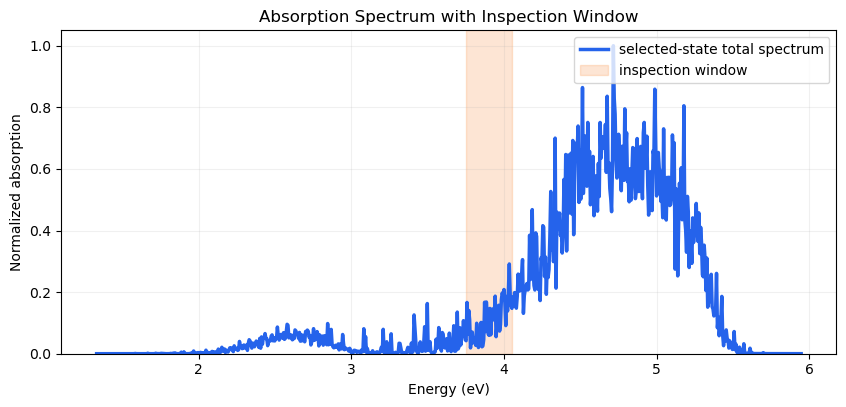

In [25]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(
    inspection.x_energy_ev,
    inspection.total_curve_normalized,
    color="#2563eb",
    linewidth=2.5,
    label="selected-state total spectrum",
)
ax.axvspan(window_min_ev, window_max_ev, color="#f97316", alpha=0.18, label="inspection window")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Normalized absorption")
ax.set_title("Absorption Spectrum with Inspection Window")
ax.set_ylim(0.0, 1.05)
ax.grid(alpha=0.18)
ax.legend(loc="upper right")
plt.show()


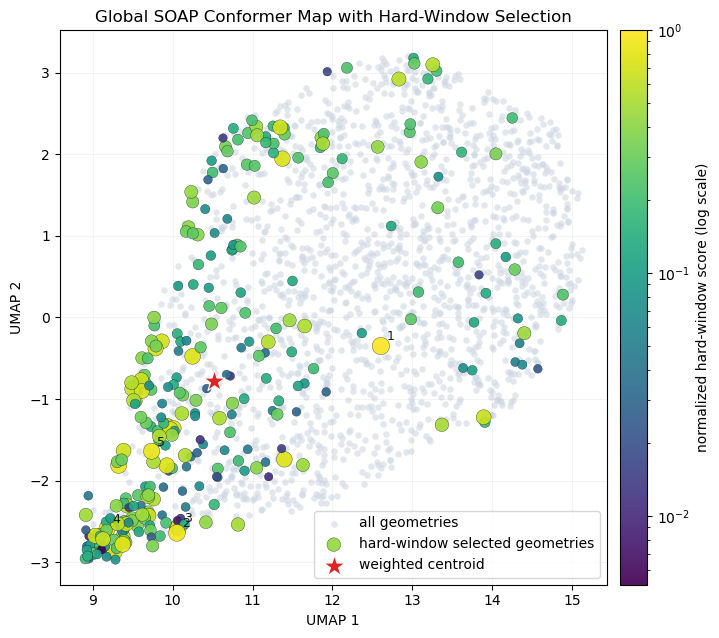

In [26]:
coords_2d = projection.coords_2d
weights = inspection.normalized_sample_window_weights
active_mask = weights > 0.0
projection_title_label = "SOAP" if projection.feature_kind.startswith("soap") else "Pair-Distance"

fig, ax = plt.subplots(figsize=(8.5, 7.2))
ax.scatter(
    coords_2d[:, 0],
    coords_2d[:, 1],
    s=22,
    color="#cbd5e1",
    alpha=0.55,
    linewidths=0.0,
    label="all geometries",
)

if np.any(active_mask):
    positive_weights = np.asarray(weights[active_mask], dtype=float)
    color_vmin = max(float(np.min(positive_weights)), 1.0e-6)
    color_vmax = max(float(np.max(positive_weights)), color_vmin * 1.0001)
    color_norm = LogNorm(vmin=color_vmin, vmax=color_vmax)
    scatter = ax.scatter(
        coords_2d[active_mask, 0],
        coords_2d[active_mask, 1],
        c=positive_weights,
        s=36.0 + 120.0 * positive_weights,
        cmap="viridis",
        norm=color_norm,
        alpha=0.92,
        edgecolors="#0f172a",
        linewidths=0.25,
        label="hard-window selected geometries",
    )
    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label("normalized hard-window score (log scale)")

    weight_sum = float(np.sum(positive_weights))
    centroid = np.sum(coords_2d[active_mask] * positive_weights[:, None], axis=0) / max(weight_sum, 1.0e-12)
    ax.scatter(
        [centroid[0]],
        [centroid[1]],
        marker="*",
        s=260,
        color="#dc2626",
        edgecolors="white",
        linewidths=0.8,
        label="weighted centroid",
        zorder=5,
    )

    top_indices = np.argsort(weights)[-5:][::-1]
    for label_index, sample_index in enumerate(top_indices.tolist(), start=1):
        if weights[sample_index] <= 0.0:
            continue
        ax.annotate(
            str(label_index),
            (coords_2d[sample_index, 0], coords_2d[sample_index, 1]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=9,
            color="#111827",
        )

if projection.method == "pca":
    xlabel = f"{projection.axis_labels[0]} ({projection.explained_variance_ratio[0] * 100.0:.1f}% var)"
    ylabel = f"{projection.axis_labels[1]} ({projection.explained_variance_ratio[1] * 100.0:.1f}% var)"
else:
    xlabel = projection.axis_labels[0]
    ylabel = projection.axis_labels[1]

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
ax.set_title(f"Global {projection_title_label} Conformer Map with Hard-Window Selection")
ax.grid(alpha=0.15)
ax.legend(loc="best")
plt.show()


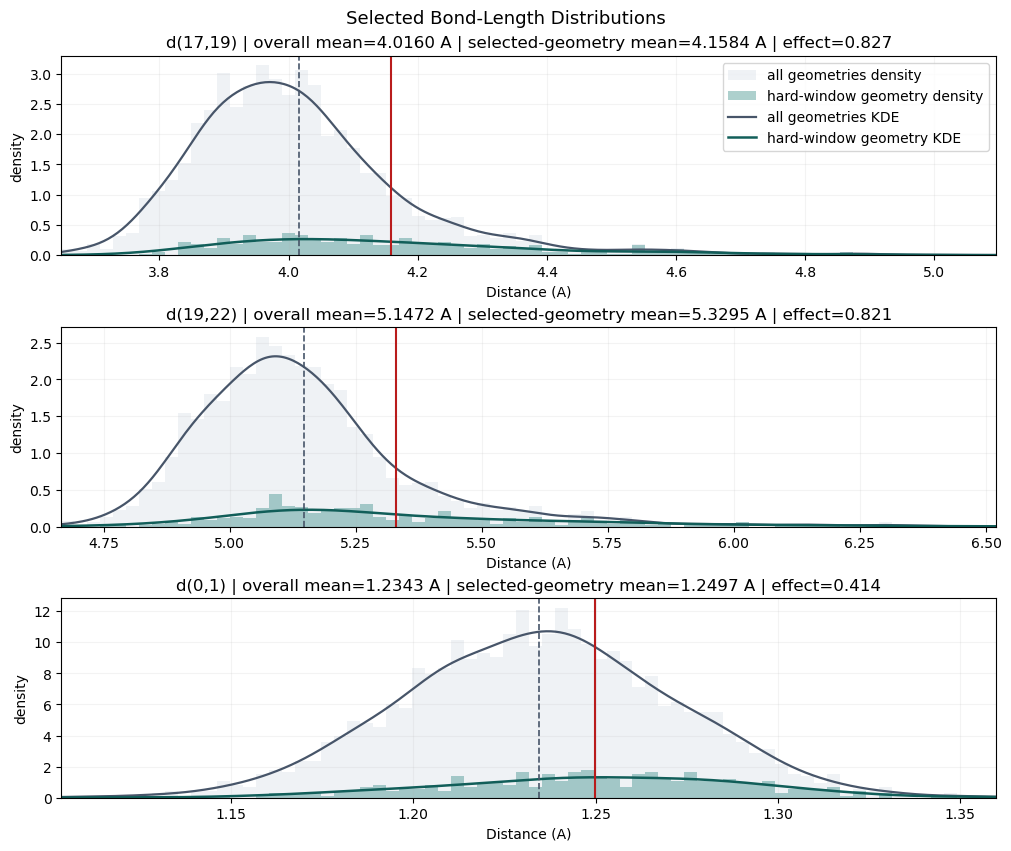

In [17]:
if SELECTED_DISTANCE_PAIRS:
    selected_bond_feature_set = build_selected_pair_distance_feature_set(
        bundle,
        atom_pairs=SELECTED_DISTANCE_PAIRS,
    )
    selected_bond_shifts = rank_descriptor_shifts(
        selected_bond_feature_set,
        structure_inspection,
        top_k=len(selected_bond_feature_set.feature_labels),
    )

    plot_count = len(selected_bond_shifts)
    fig, axes = plt.subplots(
        plot_count,
        1,
        figsize=(10, max(2.8 * plot_count, 3.4)),
        constrained_layout=True,
    )
    if plot_count == 1:
        axes = [axes]

    for axis, shift in zip(axes, selected_bond_shifts):
        plot_distribution_comparison(
            axis,
            shift.values,
            structure_inspection.sample_window_weights,
            title=(
                f"{shift.label} | overall mean={shift.overall_mean:.4f} A | "
                f"selected-geometry mean={shift.weighted_mean:.4f} A | effect={shift.effect_size:.3f}"
            ),
            xlabel="Distance (A)",
            bins=DISTRIBUTION_BIN_COUNT,
            kde_points=KDE_GRID_POINTS,
            overall_mean=shift.overall_mean,
            selected_mean=shift.weighted_mean,
            all_hist_color="#cbd5e1",
            selected_hist_color="#0f766e",
            all_kde_color="#475569",
            selected_kde_color="#115e59",
        )

    axes[0].legend(loc="upper right")
    fig.suptitle("Selected Bond-Length Distributions", fontsize=13)
    plt.show()
else:
    print("Set SELECTED_DISTANCE_PAIRS in the parameter cell to plot specific bond lengths.")


In [7]:
descriptor_shifts

[DescriptorShift(label='d(6,8)', values=array([4.0502, 3.9847, 3.8525, ..., 4.1411, 4.0839, 4.1305]), atom_pair=(6, 8), overall_mean=4.011981304411993, overall_std=0.16050054148971613, weighted_mean=4.1501764810092645, effect_size=0.8610262327752098),
 DescriptorShift(label='d(8,11)', values=array([5.1563, 5.3134, 4.913 , ..., 5.2041, 5.1859, 5.3663]), atom_pair=(8, 11), overall_mean=5.143191980110143, overall_std=0.206457009021171, weighted_mean=5.31982437187063, effect_size=0.8555407859385107),
 DescriptorShift(label='d(7,8)', values=array([3.5386, 3.4586, 3.3233, ..., 3.5803, 3.6074, 3.6782]), atom_pair=(7, 8), overall_mean=3.5357568004137674, overall_std=0.15456996013901766, weighted_mean=3.667300824745507, effect_size=0.8510322718167947),
 DescriptorShift(label='d(3,12)', values=array([3.5274, 3.3017, 3.279 , ..., 3.6282, 3.5554, 3.5011]), atom_pair=(3, 12), overall_mean=3.5253981933829373, overall_std=0.14849208396192007, weighted_mean=3.6515422498855497, effect_size=0.8495002099

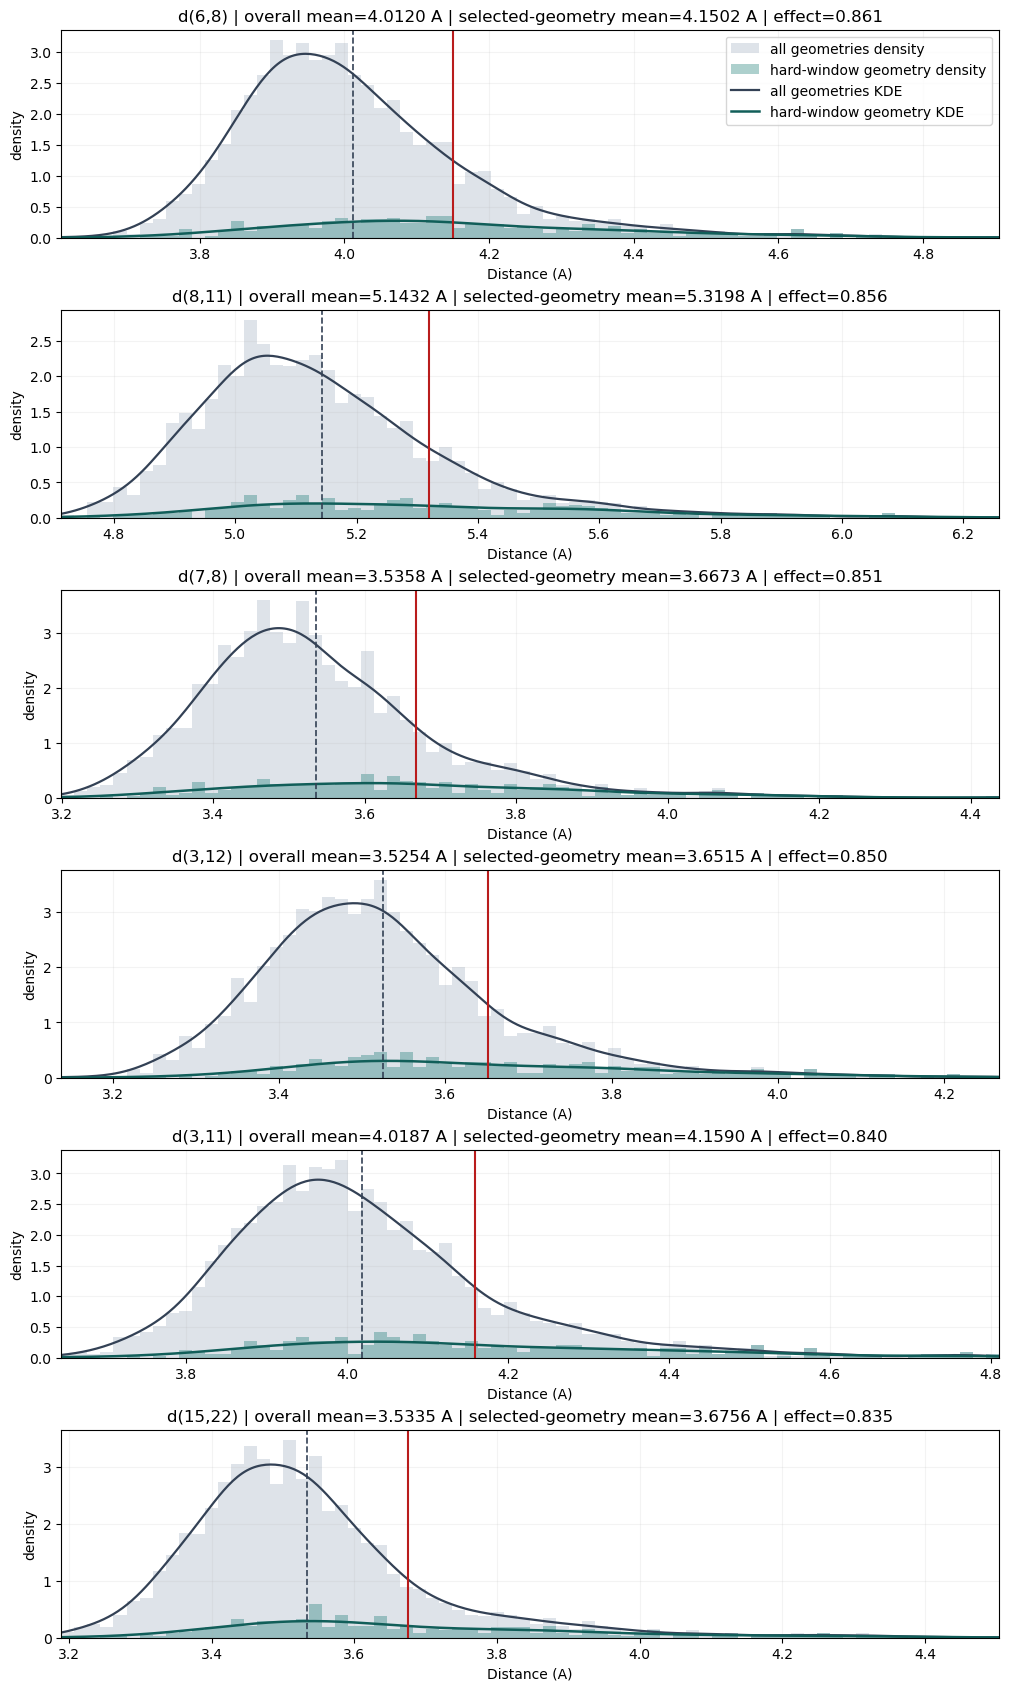

In [8]:
plot_count = len(descriptor_shifts)
fig, axes = plt.subplots(
    plot_count,
    1,
    figsize=(10, max(2.8 * plot_count, 3.4)),
    constrained_layout=True,
)
if plot_count == 1:
    axes = [axes]

for axis, shift in zip(axes, descriptor_shifts):
    plot_distribution_comparison(
        axis,
        shift.values,
        structure_inspection.sample_window_weights,
        title=(
            f"{shift.label} | overall mean={shift.overall_mean:.4f} A | "
            f"selected-geometry mean={shift.weighted_mean:.4f} A | effect={shift.effect_size:.3f}"
        ),
        xlabel="Distance (A)",
        bins=DISTRIBUTION_BIN_COUNT,
        kde_points=KDE_GRID_POINTS,
        overall_mean=shift.overall_mean,
        selected_mean=shift.weighted_mean,
    )

axes[0].legend(loc="upper right")
plt.show()


In [9]:
try:
    import pandas as pd

    display(pd.DataFrame(representative_rows))
except Exception:
    for row in representative_rows:
        print(row)

if WRITE_SELECTION:
    if USE_DEMO_BUNDLE:
        raise ValueError("Selection export requires a real bundle directory; set USE_DEMO_BUNDLE = False.")
    selection_result = run_selection(
        bundle_dir=Path(BUNDLE_DIR),
        profile_id=profile.profile_id,
        pump_energy_ev=WINDOW_CENTER_EV,
        bandwidth_ev=WINDOW_WIDTH_EV,
        target_count=SELECTION_TARGET_COUNT,
        states=STATE_FILTER,
        selection_id=SELECTION_ID,
        seed=SELECTION_SEED,
        force=False,
    )
    print(f"Wrote selection to: {selection_result.selection_dir}")
else:
    print("Set WRITE_SELECTION = True if you want to write a bundle-local selection sidecar.")


,rank,sample_idx,sample_id,weight,weight_norm,projection_method,projection_feature_kind,projection_axis_1,projection_axis_2,coord_1,coord_2,dominant_pair,dominant_excitation_ev
0,1,874,nm-sample-cCEaSWxIo6K-Odp2_sample_000874,0.414481,1.000000,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,-1.367083,-1.647751,0->2,3.873889
1,2,1893,nm-sample-cCEaSWxIo6K-Odp2_sample_001893,0.377818,0.911543,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,52.554468,-3.282873,0->3,3.965334
2,3,344,nm-sample-cCEaSWxIo6K-Odp2_sample_000344,0.359311,0.866892,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,56.434234,2.255244,0->2,3.795633
3,4,326,nm-sample-cCEaSWxIo6K-Odp2_sample_000326,0.358738,0.865511,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,86.748619,-13.037354,0->2,3.756480
4,5,1827,nm-sample-cCEaSWxIo6K-Odp2_sample_001827,0.344724,0.831698,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,52.360741,-0.326326,0->2,3.768409
5,6,167,nm-sample-cCEaSWxIo6K-Odp2_sample_000167,0.341137,0.823046,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,59.309096,23.187100,0->3,3.876812
6,7,802,nm-sample-cCEaSWxIo6K-Odp2_sample_000802,0.330881,0.798300,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,84.636860,-2.531057,0->2,3.770782
7,8,1992,nm-sample-cCEaSWxIo6K-Odp2_sample_001992,0.325309,0.784858,isomap,soap_atomwise_pooled,Isomap 1,Isomap 2,79.858134,6.227248,0->3,3.840210


Set WRITE_SELECTION = True if you want to write a bundle-local selection sidecar.
